In [1]:
import torch
import torch_geometric

C:\Users\18095\anaconda3\envs\gnn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!pip install torch-geometric -f https://data.pyg.org/whl/torch-2.5.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.5.0+cpu.html
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 21.6 MB/s  0:00:00

   ---------- -----------------------------  3/12 [multidict]
   -------------------------- -------------  8/12 [yarl]
   --------------------------------- ------ 10/12 [aiohttp]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
   ------------------------------------ --- 11/12 [torch-geometric]
 

In [2]:
%reload_ext watermark
%watermark -v -p pandas,numpy,geopandas,libpysal,esda,spreg,contextily,splot,scipy,matplotlib

Python implementation: CPython
Python version       : 3.10.20
IPython version      : 8.38.0

pandas    : 2.3.3
numpy     : 2.0.1
geopandas : 1.1.3
libpysal  : unknown
esda      : unknown
spreg     : unknown
contextily: unknown
splot     : unknown
scipy     : 1.15.3
matplotlib: 3.10.8



###  Data Exploration

In [3]:
import geopandas as gpd

gdf = gpd.read_file("D:/Glasgow/advanced topic for urban amalytics/exercise2/Assignment/AssignmentData-LondonPM25Prediction.geojson")

print(gdf.head())

print(gdf.columns)

     oa_code       PM25  k001_PCT  k002_PCT  k003_PCT  k004_PCT  k005_PCT  \
0  E00023264  16.037363  0.655567  0.733280  0.788337  0.809438  0.616867   
1  E00003359  15.571575  0.747233  0.539689  0.833211  0.720010  0.659997   
2  E00023266  16.068834  0.689326  0.758308  0.780265  0.787414  0.633875   
3  E00020264  18.205215  0.749280  0.701306  0.841211  0.773311  0.432955   
4  E00023263  16.128491  0.716956  0.743201  0.823621  0.783315  0.621155   

   k006_PCT  k007_RATIO  k008_PCT  ...  k052_PCT  k053_PCT  k054_PCT  \
0  0.048672    0.497994  0.116873  ...  0.801915  0.574316  0.565354   
1  0.155885    0.389216  0.387319  ...  0.731722  0.346726  0.750254   
2  0.151961    0.542225  0.000000  ...  0.789704  0.603182  0.551503   
3  0.000000    0.480711  0.000000  ...  0.712008  0.454649  0.413096   
4  0.073256    0.532274  0.000000  ...  0.752003  0.656612  0.372115   

   k055_PCT  k056_PCT  k057_PCT  k058_PCT  k059_PCT  k060_PCT  \
0  0.693873  0.607090  0.478002  0.5092

In [4]:
print(gdf.shape)

print(gdf.isnull().sum())

print(gdf.dtypes)

(25053, 63)
oa_code     0
PM25        0
k001_PCT    0
k002_PCT    0
k003_PCT    0
           ..
k057_PCT    0
k058_PCT    0
k059_PCT    0
k060_PCT    0
geometry    0
Length: 63, dtype: int64
oa_code       object
PM25         float64
k001_PCT     float64
k002_PCT     float64
k003_PCT     float64
              ...   
k057_PCT     float64
k058_PCT     float64
k059_PCT     float64
k060_PCT     float64
geometry    geometry
Length: 63, dtype: object


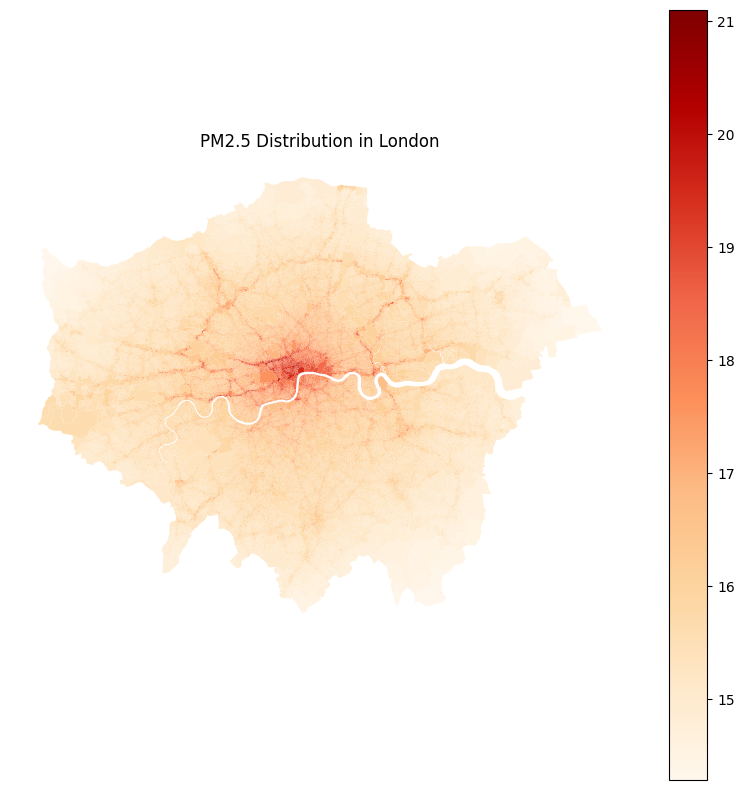

In [5]:
import matplotlib.pyplot as plt


gdf.plot(
    column="PM25",
    cmap="OrRd",
    legend=True,
    figsize=(10,10),
    edgecolor="none"   
)

plt.title("PM2.5 Distribution in London")
plt.axis("off")
plt.show()

### The spatial distribution of PM2.5 in London shows a clear pattern, with higher concentrations concentrated in central urban areas and lower levels in the outer regions. The darker red tones in central London indicate higher pollution levels, which may be associated with higher population density, traffic congestion, and urban activities. In contrast, peripheral areas exhibit lighter colours, suggesting relatively cleaner air conditions. This spatial gradient highlights the presence of strong spatial heterogeneity in air pollution, which justifies the use of graph-based models to capture spatial dependencies between neighbouring areas.

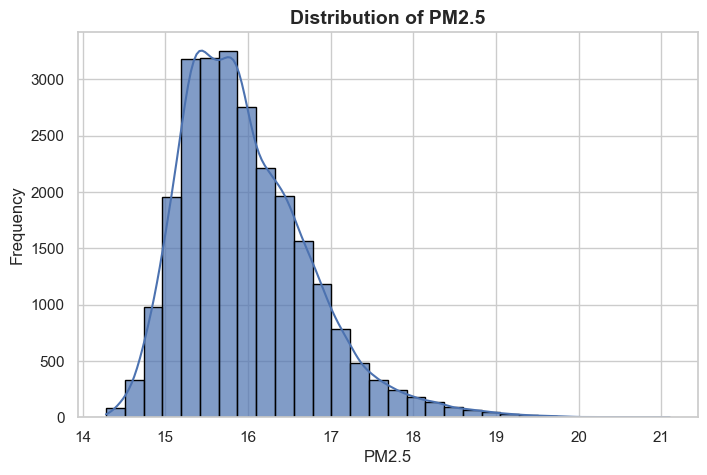

In [6]:
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(
    gdf["PM25"],
    bins=30,              
    kde=True,
    color="#4C72B0",     
    edgecolor="black",    
    alpha=0.7             
)

plt.title("Distribution of PM2.5", fontsize=14, weight="bold")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

### The distribution of PM2.5 values shows a slightly right-skewed pattern, with most observations concentrated between approximately 15 and 17 μg/m³. The peak of the distribution indicates that moderate pollution levels are most common across London. A longer tail toward higher values suggests the presence of some areas with relatively higher pollution levels, although these are less frequent. This skewed distribution indicates variability in air quality and suggests that predicting extreme values may be more challenging for the model.

### Graph Construction

In [7]:
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

In [8]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = gdf[["x", "y"]].values

k = 5  
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
distances, indices = nbrs.kneighbors(coords)

edge_index = []

for i in range(len(indices)):
    for j in indices[i][1:]: 
        edge_index.append([i, j])

edge_index = np.array(edge_index).T

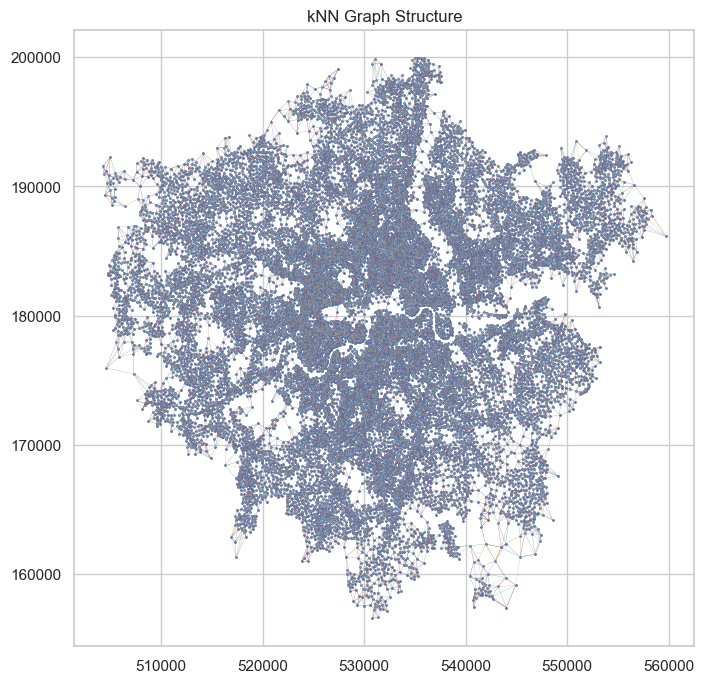

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(coords[:,0], coords[:,1], s=1)

for i in range(edge_index.shape[1]):
    x1, y1 = coords[edge_index[0, i]]
    x2, y2 = coords[edge_index[1, i]]
    plt.plot([x1, x2], [y1, y2], linewidth=0.2)

plt.title("kNN Graph Structure")
plt.show()

### The k-nearest neighbours (kNN) graph illustrates the spatial connectivity between Output Areas in London, where each node is connected to its five closest neighbours based on centroid distance. The resulting network shows a dense and well-connected structure, ensuring that all nodes are integrated into the graph without isolation. This connectivity enables the Graph Neural Network to effectively propagate information across neighbouring areas, capturing local spatial dependencies. The kNN approach is particularly suitable as it provides a consistent number of connections for each node and avoids irregularities that may arise from purely adjacency-based methods.

### Graph Neural Network

In [59]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

x = torch.tensor(gdf[feature_columns].values, dtype=torch.float)
y = torch.tensor(gdf['PM25'].values, dtype=torch.float).view(-1, 1)
edge_index = torch.tensor(edge_index, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

C:\Users\18095\AppData\Local\Temp\ipykernel_24144\2440822097.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(edge_index, dtype=torch.long)


In [60]:
# Standardise features X
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(data.x.numpy())
data.x = torch.tensor(x_scaled, dtype=torch.float)

# Standardise target Y 
scaler_y = StandardScaler()
y_np = data.y.numpy().reshape(-1, 1)
y_scaled = scaler_y.fit_transform(y_np)
data.y_scaled = torch.tensor(y_scaled, dtype=torch.float)

num_nodes = data.num_nodes
indices = np.random.permutation(num_nodes)
train_size = int(0.8 * num_nodes)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

In [61]:
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return self.out(x)

In [62]:
model = GCN(input_dim=data.num_features, hidden_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y_scaled[train_idx])
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    pred_scaled = model(data.x, data.edge_index)
    pred = scaler_y.inverse_transform(pred_scaled.numpy()).flatten()
    actual = y_np.flatten()

gnn_rmse = np.sqrt(mean_squared_error(actual[test_idx], pred[test_idx]))
gnn_r2 = r2_score(actual[test_idx], pred[test_idx])

print(f"\n[GNN Results] RMSE: {gnn_rmse:.4f}, R2: {gnn_r2:.4f}")

Epoch 000 | Loss: 0.9033
Epoch 050 | Loss: 0.1848
Epoch 100 | Loss: 0.1650
Epoch 150 | Loss: 0.1499
Epoch 200 | Loss: 0.1362
Epoch 250 | Loss: 0.1256

[GNN Results] RMSE: 0.2840, R2: 0.8691


In [63]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_scaled[train_idx], y_np[train_idx].ravel())
rf_pred = rf.predict(x_scaled[test_idx])

rf_rmse = np.sqrt(mean_squared_error(actual[test_idx], rf_pred))
rf_r2 = r2_score(actual[test_idx], rf_pred)

print(f"[RF Baseline Results] RMSE: {rf_rmse:.4f}, R2: {rf_r2:.4f}")

[RF Baseline Results] RMSE: 0.3588, R2: 0.7911


### Results & Interpretation

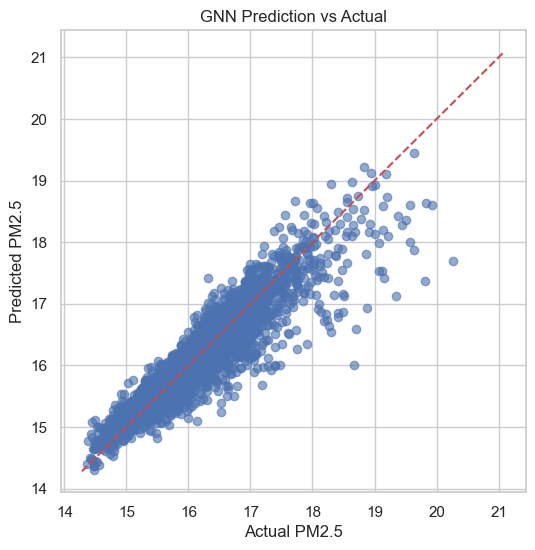

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(actual[test_idx], pred[test_idx], alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--')  # y=x 参考线
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("GNN Prediction vs Actual")
plt.show()

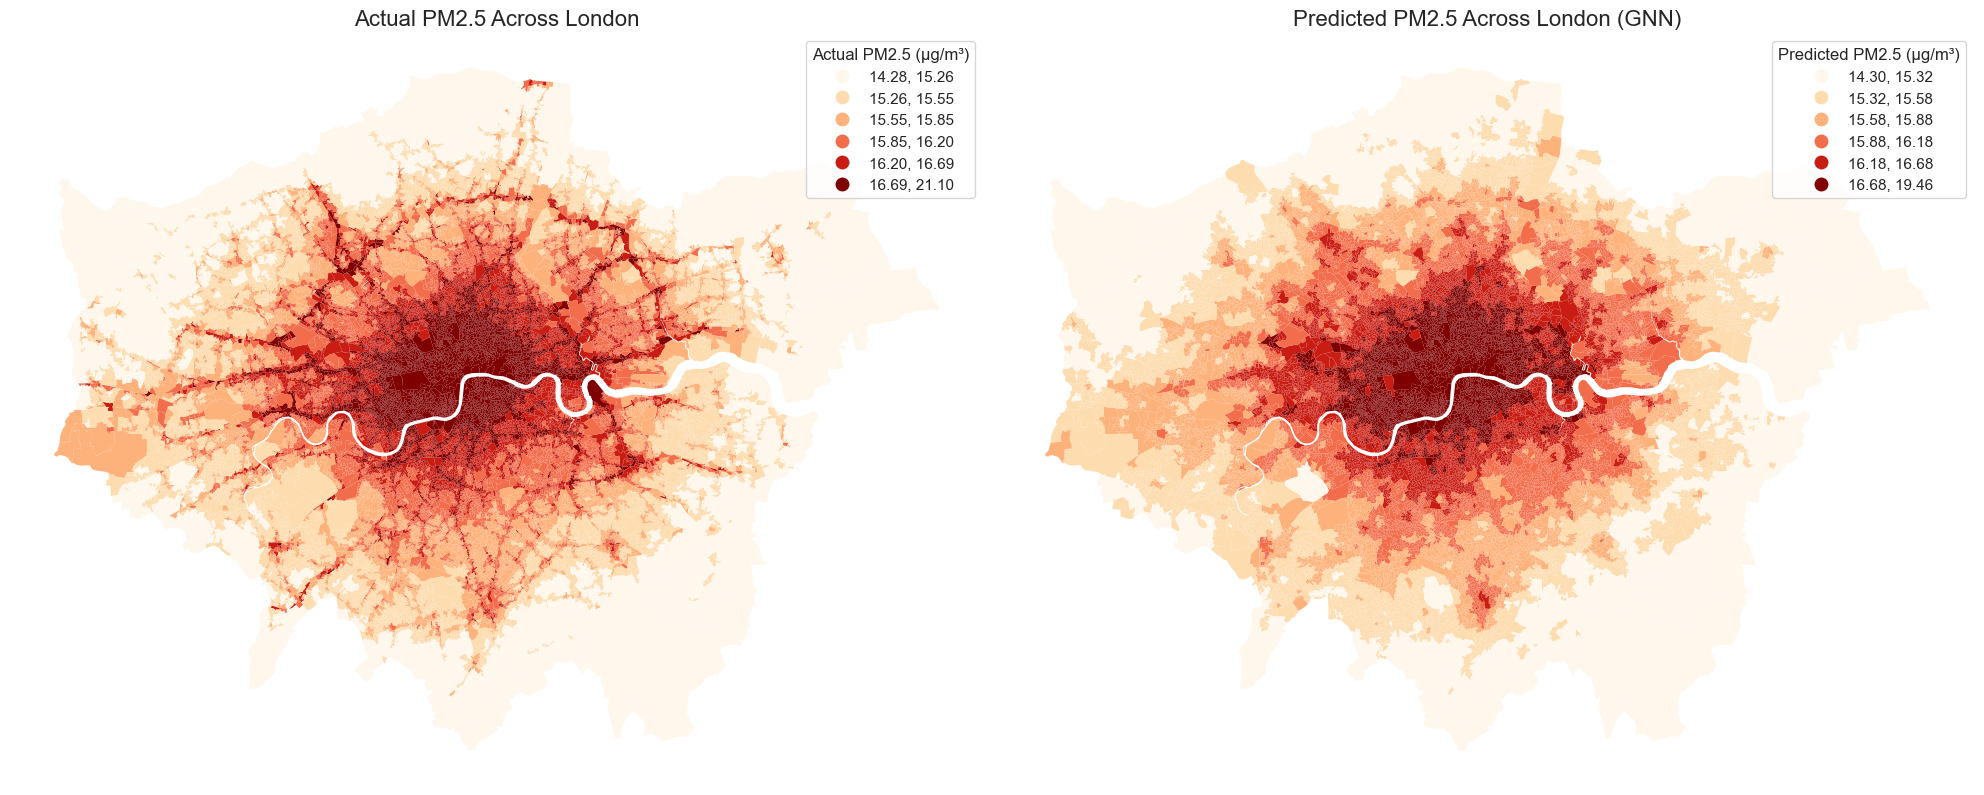

In [84]:
import matplotlib.pyplot as plt
import mapclassify  

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

gdf.plot(
    column='PM25', 
    ax=axes[0], 
    cmap='OrRd',           
    legend=True,
    scheme='quantiles',    
    k=6,                  
    edgecolor='none',       
    legend_kwds={'title': "Actual PM2.5 (µg/m³)"}
)
axes[0].set_title("Actual PM2.5 Across London", fontsize=16)
axes[0].axis('off')

gdf.plot(
    column='PM25_pred', 
    ax=axes[1], 
    cmap='OrRd',          
    legend=True,
    scheme='quantiles', 
    k=6,
    edgecolor='none',
    legend_kwds={'title': "Predicted PM2.5 (µg/m³)"}
)
axes[1].set_title("Predicted PM2.5 Across London (GNN)", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

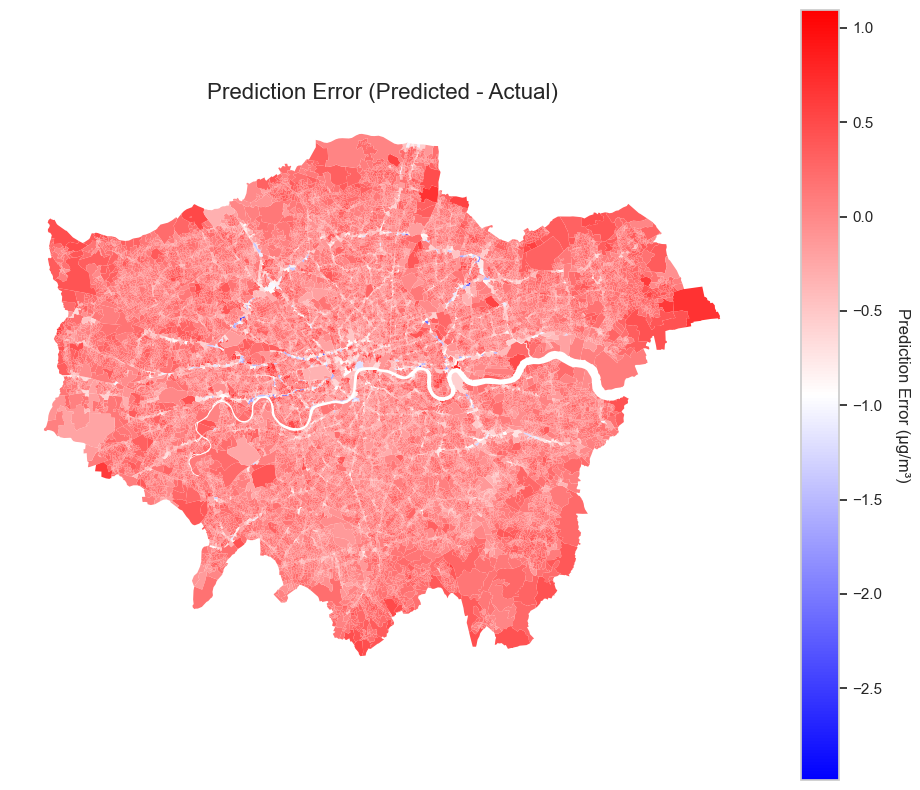

In [86]:
import matplotlib.pyplot as plt

# 计算误差
gdf['PM25_diff'] = gdf['PM25_pred'] - gdf['PM25']

fig, ax = plt.subplots(figsize=(12, 10))

# 绘制误差图
plot = gdf.plot(
    column='PM25_diff',
    ax=ax,
    cmap='bwr',       # 蓝红双色
    legend=True,
    edgecolor='none'
)

# 获取 colorbar 并设置标题
cbar = plot.get_figure().get_axes()[1]  # GeoPandas 会自动生成 colorbar
cbar.set_ylabel("Prediction Error (µg/m³)", rotation=270, labelpad=20, fontsize=12)

ax.set_title("Prediction Error (Predicted - Actual)", fontsize=16)
ax.axis('off')
plt.show()

### The spatial distribution of prediction errors shows that most areas exhibit small deviations between predicted and actual PM2.5 values, indicating generally good model performance across London. The predominance of light red tones suggests a slight overall tendency for overestimation, while only a few areas display larger negative errors (blue regions), indicating underestimation. Spatially, errors appear relatively evenly distributed, with no strong clustering of extreme errors, suggesting that the model is stable across different regions. However, some localized variations indicate that certain urban characteristics or complex spatial interactions may not be fully captured by the model.